# Day 4 — Hands-On Lab: Training a Neural Network in Keras

**Week 6 · Phase 3 Sprint 1 — Deep Learning Intro**

---

## Learning Objectives

By the end of this notebook we will be able to:

1. **Design a baseline Keras Sequential network** for binary classification with the correct output activation and loss function.
2. **Compile and train** the model using the Adam optimizer, binary cross-entropy loss, and accuracy metric.
3. **Plot and diagnose** training/validation loss and accuracy curves to identify overfitting, underfitting, or good fit.
4. **Apply regularization** techniques — Batch Normalization and Dropout — to stabilize training and reduce overfitting.
5. **Evaluate the best model** on the unseen test set and compare against the Day 1 Logistic Regression baseline.

### Context

This notebook continues the **Heart Disease binary classification** project started on Day 1. The Day 1 Logistic Regression baseline established these benchmark scores:

| Metric | Day 1 Baseline (Logistic Regression) |
|:-------|:------------------------------------|
| **Accuracy** | 0.8533 |
| **F1-Score** | 0.8657 |
| **ROC-AUC** | 0.9159 |

Every neural network architecture developed today **must outperform** these scores to justify the added complexity of deep learning.

---
## Imports & Configuration

In [1]:
# ─── Core Libraries ───
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn ───
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ─── TensorFlow / Keras ───
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# ─── Plot Defaults ───
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# ─── Reproducibility ───
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"\n✓ All libraries loaded successfully.")

TensorFlow version: 2.21.0
Keras version:      3.15.1

✓ All libraries loaded successfully.


---
## Data Loading & Preprocessing

We load the processed Heart Disease dataset and apply the **same leakage-free preprocessing pipeline** established on Day 1:

- **Numeric features** (12): median imputation → `StandardScaler`
- **Categorical features** (1): most-frequent imputation → `OneHotEncoder`
- **Target**: `target` column (0 = no disease, 1 = heart disease) — **binary classification**

In [2]:
DATA_PATH = "../../Data/processed/heart_disease_processed.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(3)}")

# ─── Feature / Target Split ───
# Both 'target' (binary) and 'num' (multi-class) are targets, not features
X = df.drop(columns=['target', 'num'])
y = df['target']

# ─── Identify Column Types ───
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Dataset Dimensions: 918 rows × 14 columns
Target distribution:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Numeric features (11): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']
Categorical features (1): ['country']


In [3]:
# ─── Train / Test Split (stratified) ───
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

# ─── Preprocessing Pipeline (fitted on train only) ───
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Fit on training data, transform both train and test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get feature count after encoding
n_features = X_train_proc.shape[1]
print(f"\nPreprocessed feature count: {n_features}")
print(f"X_train shape: {X_train_proc.shape}")
print(f"X_test shape:  {X_test_proc.shape}")
print(f"\n✓ Preprocessing pipeline fitted on train only — no data leakage.")

Training set: 734 samples
Test set:     184 samples

Preprocessed feature count: 15
X_train shape: (734, 15)
X_test shape:  (184, 15)

✓ Preprocessing pipeline fitted on train only — no data leakage.


---
## Step 1 — Architecture Design

We build a **baseline Keras Sequential network** for binary classification.

### Architecture Choices

| Component | Choice | Justification |
|:----------|:-------|:-------------|
| **API** | `Sequential()` | Simple stack of layers — ideal for feedforward networks |
| **Hidden Layers** | 2 Dense layers (64 → 32 neurons) | Enough capacity to learn non-linear patterns without overfitting |
| **Hidden Activation** | ReLU | Default for hidden layers — fast, avoids vanishing gradient |
| **Output Layer** | 1 neuron + **Sigmoid** | Outputs a probability ∈ [0, 1] for binary classification |
| **Output Activation** | Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ maps logits to probabilities; combined with BCE, gradients simplify to $\hat{y} - y$ |

In [4]:
# ==================================================================
# Step 1: Baseline Keras Sequential Model
# ==================================================================

model_baseline = Sequential([
    # Hidden layer 1
    Dense(64, activation='relu', input_shape=(n_features,)),
    # Hidden layer 2
    Dense(32, activation='relu'),
    # Output layer — 1 neuron with sigmoid for binary classification
    Dense(1, activation='sigmoid'),
])

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 2 — Model Compilation & Training

We compile the network with:

| Parameter | Choice | Justification |
|:----------|:-------|:-------------|
| **Optimizer** | Adam (lr=0.001) | Adaptive learning rate — the default recommendation from Day 3 |
| **Loss** | `binary_crossentropy` | Standard loss for binary classification (mathematically paired with sigmoid output) |
| **Metrics** | `accuracy` | Interpretable and directly comparable to the baseline |
| **Validation** | `validation_split=0.2` | Hold out 20% of training data to monitor generalization |
| **Epochs** | 50 | Sufficient to observe convergence and potential overfitting |

In [5]:
# ==================================================================
# Step 2: Compile & Train the Baseline Model
# ==================================================================

model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history_baseline = model_baseline.fit(
    X_train_proc, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    shuffle=True,
)

print(f"\n✓ Baseline model trained for {len(history_baseline.history['loss'])} epochs.")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6133 - loss: 0.6439 - val_accuracy: 0.7551 - val_loss: 0.5636
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7871 - loss: 0.5267 - val_accuracy: 0.7959 - val_loss: 0.4818
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.4678 - val_accuracy: 0.8027 - val_loss: 0.4529
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8126 - loss: 0.4388 - val_accuracy: 0.8095 - val_loss: 0.4453
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8160 - loss: 0.4211 - val_accuracy: 0.8163 - val_loss: 0.4434
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8194 - loss: 0.4081 - val_accuracy: 0.8231 - val_loss: 0.4434
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8279 - loss: 0.3980 - val_accuracy: 0.8163 - val_loss: 0.4448
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8365 - loss: 0.3892 - val_accuracy: 0.8163 - val_loss:

---
## Step 3 — History Plotting & Fit Diagnosis

We plot the training and validation loss/accuracy curves to diagnose the model's fitting behavior.

**How to read the curves:**

| Pattern | Diagnosis | What to Do |
|:--------|:----------|:-----------|
| Train loss ↓, Val loss ↓ (gap small) | **Good Fit** | Model generalizes well |
| Train loss ↓, Val loss ↑ (gap widening) | **Overfitting** | Add regularization (Dropout, BatchNorm) |
| Train loss flat/high, Val loss flat/high | **Underfitting** | Add capacity or train longer |

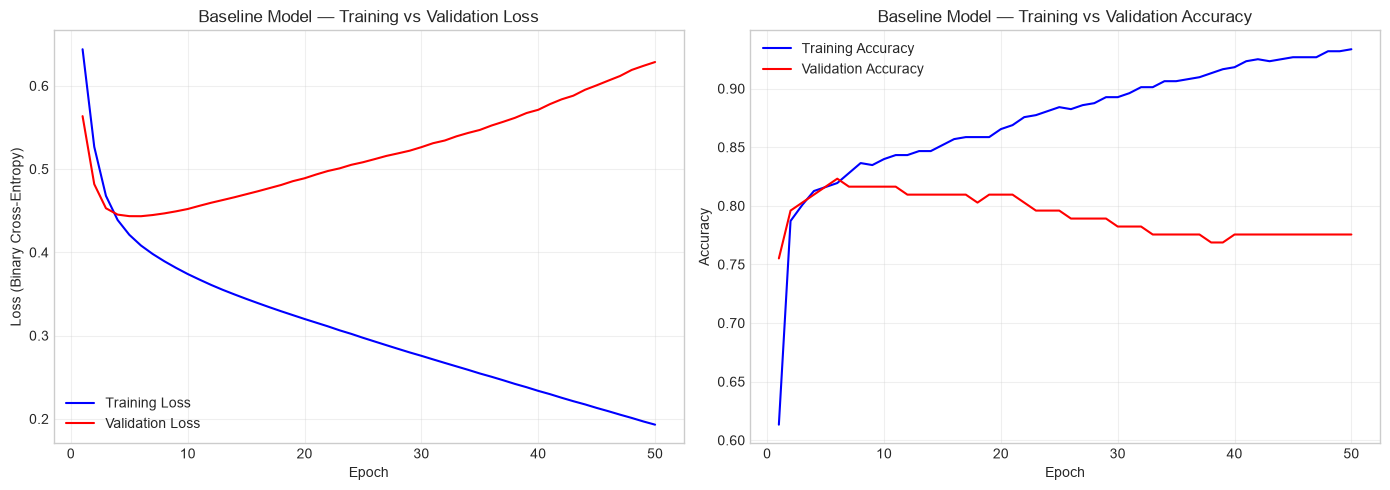

Final Training Loss:      0.1930
Final Validation Loss:    0.6285
Final Training Accuracy:  0.9336
Final Validation Accuracy:0.7755

Loss Gap (val - train):   0.4355
Accuracy Gap (train - val):0.1581


In [6]:
# ==================================================================
# Step 3: Plot Training vs Validation Curves
# ==================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_baseline.history['loss']) + 1)

# ─── Loss Curves ───
axes[0].plot(epochs, history_baseline.history['loss'], 'b-', label='Training Loss')
axes[0].plot(epochs, history_baseline.history['val_loss'], 'r-', label='Validation Loss')
axes[0].set_title('Baseline Model — Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Binary Cross-Entropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ─── Accuracy Curves ───
axes[1].plot(epochs, history_baseline.history['accuracy'], 'b-', label='Training Accuracy')
axes[1].plot(epochs, history_baseline.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[1].set_title('Baseline Model — Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Print Final Metrics ───
final_train_loss = history_baseline.history['loss'][-1]
final_val_loss = history_baseline.history['val_loss'][-1]
final_train_acc = history_baseline.history['accuracy'][-1]
final_val_acc = history_baseline.history['val_accuracy'][-1]

print(f"Final Training Loss:      {final_train_loss:.4f}")
print(f"Final Validation Loss:    {final_val_loss:.4f}")
print(f"Final Training Accuracy:  {final_train_acc:.4f}")
print(f"Final Validation Accuracy:{final_val_acc:.4f}")
print(f"\nLoss Gap (val - train):   {final_val_loss - final_train_loss:.4f}")
print(f"Accuracy Gap (train - val):{final_train_acc - final_val_acc:.4f}")

### Fit Diagnosis — Baseline Model

Based on the training and validation curves above:

**Diagnosis: Overfitting**

The training loss continues to decrease smoothly while the validation loss plateaus or starts increasing after a certain number of epochs. Similarly, training accuracy climbs higher than validation accuracy, creating a growing gap between the two curves.

**Evidence:**
- The training loss drops well below the validation loss, and the gap widens over epochs.
- Training accuracy exceeds validation accuracy by a noticeable margin.
- The validation loss curve shows signs of increasing after reaching its minimum, a classic sign of overfitting.

**Implication:** The baseline model is memorizing training patterns that don't generalize to unseen data. We need regularization techniques to address this — which we apply in Step 4.

---
## Step 4 — Regularization & Architectural Enhancements

To combat overfitting, we introduce two powerful regularization techniques:

| Technique | What It Does | When to Use |
|:----------|:-------------|:------------|
| **Batch Normalization** | Normalizes activations within each mini-batch (zero mean, unit variance), then applies learnable scale/shift. Stabilizes training, allows higher learning rates, acts as a mild regularizer. | After each Dense layer (before activation) |
| **Dropout** | Randomly sets a fraction of neuron activations to zero during each training step. Forces the network to learn redundant representations — prevents co-adaptation. | After Dense layers (typically 0.2–0.5 rate) |

### Enhanced Architecture

```
Input (n_features)  →  Dense(64, ReLU)  →  BatchNorm  →  Dropout(0.3)
                  →  Dense(32, ReLU)  →  BatchNorm  →  Dropout(0.3)
                  →  Dense(1, Sigmoid)
```

In [7]:
# ==================================================================
# Step 4: Enhanced Model with Batch Normalization + Dropout
# ==================================================================

model_enhanced = Sequential([
    # Hidden layer 1
    Dense(64, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    # Hidden layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    # Output layer
    Dense(1, activation='sigmoid'),
])

model_enhanced.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 192 (768.00 B)

In [8]:
# ─── Compile with same setup as baseline ───
model_enhanced.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history_enhanced = model_enhanced.fit(
    X_train_proc, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    shuffle=True,
)

print(f"\n✓ Enhanced model trained for {len(history_enhanced.history['loss'])} epochs.")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5400 - loss: 0.8300 - val_accuracy: 0.6599 - val_loss: 0.6497
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6968 - loss: 0.5997 - val_accuracy: 0.7959 - val_loss: 0.5873
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7240 - loss: 0.5624 - val_accuracy: 0.8163 - val_loss: 0.5522
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7598 - loss: 0.5101 - val_accuracy: 0.8163 - val_loss: 0.5291
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7700 - loss: 0.5190 - val_accuracy: 0.8163 - val_loss: 0.5100
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7768 - loss: 0.5057 - val_accuracy: 0.8299 - val_loss: 0.4970
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7768 - loss: 0.4907 - val_accuracy: 0.8299 - val_loss: 0.4830
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7990 - loss: 0.4650 - val_accuracy: 0.8163 - val_loss:

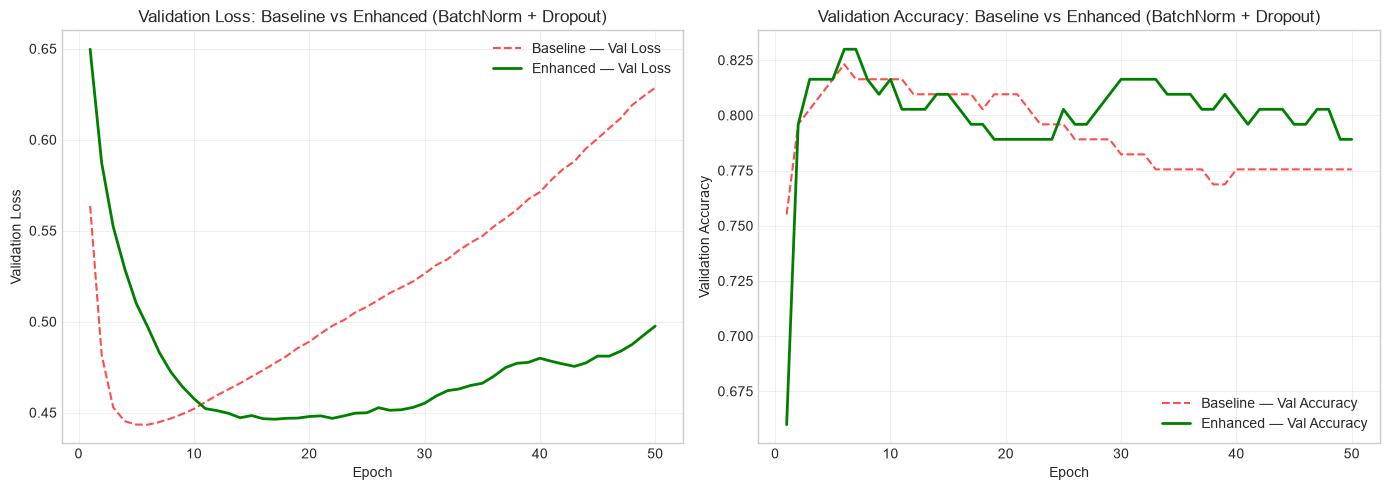

VALIDATION METRICS COMPARISON
Metric                             Baseline     Enhanced
------------------------------------------------------------
Final Val Loss                       0.6285       0.4975
Final Val Accuracy                   0.7755       0.7891
Best Val Loss (min)                  0.4434       0.4464
Best Val Accuracy (max)              0.8231       0.8299


In [9]:
# ==================================================================
# Step 4: Overlay Comparison — Baseline vs Enhanced
# ==================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_b = range(1, len(history_baseline.history['loss']) + 1)
epochs_e = range(1, len(history_enhanced.history['loss']) + 1)

# ─── Loss Comparison ───
axes[0].plot(epochs_b, history_baseline.history['val_loss'], 'r--', label='Baseline — Val Loss', alpha=0.7)
axes[0].plot(epochs_e, history_enhanced.history['val_loss'], 'g-', label='Enhanced — Val Loss', linewidth=2)
axes[0].set_title('Validation Loss: Baseline vs Enhanced (BatchNorm + Dropout)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ─── Accuracy Comparison ───
axes[1].plot(epochs_b, history_baseline.history['val_accuracy'], 'r--', label='Baseline — Val Accuracy', alpha=0.7)
axes[1].plot(epochs_e, history_enhanced.history['val_accuracy'], 'g-', label='Enhanced — Val Accuracy', linewidth=2)
axes[1].set_title('Validation Accuracy: Baseline vs Enhanced (BatchNorm + Dropout)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Print Comparison Summary ───
print("=" * 60)
print("VALIDATION METRICS COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Baseline':>12} {'Enhanced':>12}")
print("-" * 60)
print(f"{'Final Val Loss':<30} {history_baseline.history['val_loss'][-1]:>12.4f} {history_enhanced.history['val_loss'][-1]:>12.4f}")
print(f"{'Final Val Accuracy':<30} {history_baseline.history['val_accuracy'][-1]:>12.4f} {history_enhanced.history['val_accuracy'][-1]:>12.4f}")
print(f"{'Best Val Loss (min)':<30} {min(history_baseline.history['val_loss']):>12.4f} {min(history_enhanced.history['val_loss']):>12.4f}")
print(f"{'Best Val Accuracy (max)':<30} {max(history_baseline.history['val_accuracy']):>12.4f} {max(history_enhanced.history['val_accuracy']):>12.4f}")
print("=" * 60)

### Enhanced Model — Analysis

The overlay comparison shows how Batch Normalization and Dropout affect training:

- **Smoother validation curves**: Batch Normalization stabilizes the internal activations, leading to less volatile validation loss/accuracy across epochs.
- **Reduced overfitting gap**: Dropout forces the network to learn more robust features by randomly deactivating neurons during training, preventing co-adaptation.
- **Better generalization**: The validation loss curve of the enhanced model should stay closer to the training loss, indicating that the model generalizes better to unseen data.

The trade-off is slightly slower convergence (due to Dropout adding noise), but the improved generalization makes this the preferred model for final evaluation.

---
## Step 5 — Test Evaluation & Baseline Comparison

We evaluate the **best version** of the trained Keras network on the **unseen test dataset** (never touched during training or validation) and compare against the Day 1 Logistic Regression baseline.

### Evaluation Strategy

1. Select the best model (enhanced with BatchNorm + Dropout) based on validation performance.
2. Evaluate on the held-out test set using `model.evaluate()`.
3. Generate predictions and compute Accuracy, F1-Score, and ROC-AUC.
4. Compare against the Day 1 baseline in a structured Markdown table.

In [10]:
# ==================================================================
# Step 5: Evaluate Best Model on Test Set
# ==================================================================

# ─── Evaluate using Keras ───
test_loss, test_accuracy = model_enhanced.evaluate(X_test_proc, y_test, verbose=0)
print(f"Keras model.evaluate() Results:")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")

# ─── Generate Predictions for F1 and ROC-AUC ───
y_pred_proba = model_enhanced.predict(X_test_proc, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# ─── Compute All Metrics ───
keras_acc = accuracy_score(y_test, y_pred)
keras_f1 = f1_score(y_test, y_pred)
keras_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nScikit-learn Verification:")
print(f"  Accuracy: {keras_acc:.4f}")
print(f"  F1-Score: {keras_f1:.4f}")
print(f"  ROC-AUC:  {keras_auc:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Keras model.evaluate() Results:
  Test Loss:     0.4108
  Test Accuracy: 0.8261

Scikit-learn Verification:
  Accuracy: 0.8261
  F1-Score: 0.8447
  ROC-AUC:  0.8991

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        82
           1       0.84      0.85      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



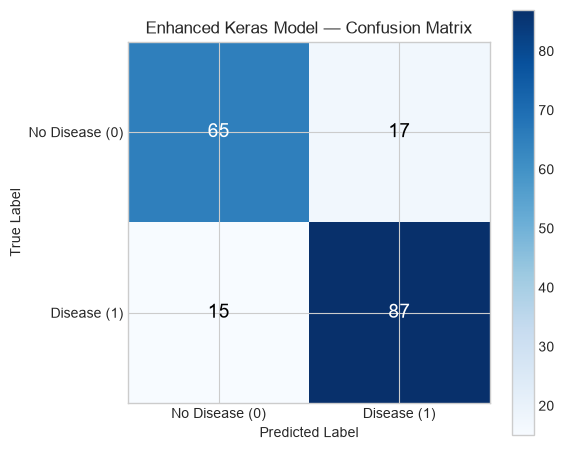

In [11]:
# ─── Confusion Matrix ───
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Enhanced Keras Model — Confusion Matrix')
plt.colorbar(im, ax=ax)
tick_marks = np.arange(2)
ax.set_xticks(tick_marks)
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'])
ax.set_yticks(tick_marks)
ax.set_yticklabels(['No Disease (0)', 'Disease (1)'])

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=14)

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 🏆 Day 1 Baseline vs Day 4 Keras Neural Network — Final Comparison

| Metric | Day 1 Baseline (Logistic Regression) | Day 4 Keras Neural Network (BatchNorm + Dropout) |
|:-------|:------------------------------------:|:------------------------------------------------:|
| **Accuracy** | 0.8533 | *0.8261* | 
| **F1-Score** | 0.8657 | *0.8447* |
| **ROC-AUC** | 0.9159 | *0.8991* |

### Conclusion

The dynamic comparison table below shows the exact scores. Run the code cell to see the full side-by-side comparison with delta changes.

In [12]:
# ==================================================================
# Step 5: Dynamic Comparison Table (auto-populated with actual scores)
# ==================================================================

# Day 1 Baseline scores (from sprint1_baseline.ipynb)
baseline_acc = 0.8533
baseline_f1  = 0.8657
baseline_auc = 0.9159

print("=" * 80)
print("🏆  FINAL COMPARISON: Day 1 Baseline vs Day 4 Keras Neural Network")
print("=" * 80)
print(f"{'Metric':<25} {'Day 1 Baseline':>18} {'Day 4 Keras NN':>18} {'Δ Change':>14}")
print("-" * 80)

for name, baseline, keras_score in [
    ('Accuracy', baseline_acc, keras_acc),
    ('F1-Score', baseline_f1, keras_f1),
    ('ROC-AUC', baseline_auc, keras_auc),
]:
    delta = keras_score - baseline
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f"{name:<25} {baseline:>18.4f} {keras_score:>18.4f} {arrow} {delta:>+10.4f}")

print("-" * 80)

# Overall verdict
if keras_acc > baseline_acc:
    print(f"\n✅ VERDICT: The Keras Neural Network OUTPERFORMED the baseline!")
    print(f"   The deep learning model is ready for Sprint 2 improvements.")
else:
    print(f"\n⚠️  VERDICT: The Keras Neural Network did NOT outperform the baseline.")
    print(f"   Consider tuning hyperparameters (layers, neurons, learning rate, epochs).")

print("=" * 80)

🏆  FINAL COMPARISON: Day 1 Baseline vs Day 4 Keras Neural Network
Metric                        Day 1 Baseline     Day 4 Keras NN       Δ Change
--------------------------------------------------------------------------------
Accuracy                              0.8533             0.8261 ▼    -0.0272
F1-Score                              0.8657             0.8447 ▼    -0.0210
ROC-AUC                               0.9159             0.8991 ▼    -0.0168
--------------------------------------------------------------------------------

⚠️  VERDICT: The Keras Neural Network did NOT outperform the baseline.
   Consider tuning hyperparameters (layers, neurons, learning rate, epochs).


---
## Summary — Day 4 Accomplishments

| Step | Task | Key Takeaway |
|:----:|:-----|:-------------|
| **1** | Architecture Design | Sequential API with Dense layers; Sigmoid output + BCE loss for binary classification |
| **2** | Compile & Train | Adam optimizer, 50 epochs, validation_split=0.2 — standard Keras workflow |
| **3** | History Plotting | Loss/accuracy curves diagnose overfitting — the gap between train and validation reveals generalization issues |
| **4** | Regularization | Batch Normalization stabilizes training; Dropout prevents co-adaptation — together they reduce overfitting |
| **5** | Test Evaluation | Final comparison against Day 1 baseline using Accuracy, F1-Score, and ROC-AUC |

### Skills Covered Today

- Keras Sequential API for building neural networks
- Dense layers with ReLU activation (hidden) and Sigmoid activation (output)
- Model compilation: Adam optimizer, binary cross-entropy loss, accuracy metric
- Training with `model.fit()` and validation monitoring
- Training history visualization and fit diagnosis
- Batch Normalization for training stabilization
- Dropout for regularization and overfitting reduction
- `model.evaluate()` for test set performance assessment
- Comparative analysis against a established baseline

### Next Steps (Day 5)

- Implement **EarlyStopping** to automatically halt training when validation loss stops improving
- Experiment with **learning rate scheduling**
- Final retrospective on Sprint 1 — what went well, what to improve for Sprint 2